# Entwicklung der Menschenrechte weltweit: Veränderungen im Human Rights Index (1950-2024)
## Abgabetermin
<span style="color:blue; font-weight:bold"> 21. Dezember 2025</span>
## Gruppenmitglieder
### Alessandro Zandt 
E-Mail: zandtale@students.zhaw.ch
### David Hascher
E-Mail: haschdav@students.zhaw.ch
### Tauland Strellci
E-Mail: streltau@students.zhaw.ch
## Kurzer Projektbeschrieb
In diesem Projekt analysieren wir die zeitliche Entwicklung des Human Rights Index für verschiedene Länder.
Der Datensatz Human Rights Index von V-Dem misst, wie stark grundlegende Menschenrechte in einzelnen Ländern geschützt sind. Der Index basiert auf Expertenschätzungen und umfasst zentrale Bereiche wie:

- Schutz vor staatlicher Gewalt (Tortur, politische Morde, Zwangsarbeit)

- Rechte auf Eigentum

- Bewegungsfreiheit

- Religionsfreiheit

- Meinungs- und Pressefreiheit

- Vereinigungsfreiheit

Der Index reicht von 0 bis 1, wobei 1 ein sehr hohes Schutzniveau der Menschenrechte darstellt.


### Datensatz
Quelle: https://ourworldindata.org/vdem-human-rights-data
### Fragestellung

<span style="color:blue; font-weight:bold"> Wie haben sich die Menschenrechte in verschiedenen Ländern in den letzten Jahren entwickelt, und welche drei Staaten verzeichnen die stärksten Verbesserungen bzw. Verschlechterungen zwischen 1950 und 2024?</span>



## 1. Daten beschaffen und laden

Den Datensatz konnten wir in passender Form direkt von der Webseite "Our World in Data" herunterladen. Ein Link zur Webseite wurde oben unter "Quelle" eingefügt.

In [130]:

import pandas as pd
from matplotlib import pyplot as plt
import requests

import pandas as pd




Der Vollständigkeit halber hier noch das Format des ursprünglichen Datensatzes:

In [131]:
df = pd.read_csv("human-rights-index-vdem.csv")
df.head()

,Entity,Code,Year,civ_libs_vdem__estimate_best,owid_region
0,Afghanistan,AFG,1789,0.121,NaN
1,Afghanistan,AFG,1790,0.121,NaN
2,Afghanistan,AFG,1791,0.121,NaN
3,Afghanistan,AFG,1792,0.121,NaN
4,Afghanistan,AFG,1793,0.121,NaN


## 2. Daten vorbereiten


Die Daten lagen zunächst noch nicht in einem geeigneten Format vor. Wir nutzten den Befehl df.head(), um die ersten fünf Zeilen darzustellen. Auf dieser Grundlage trafen wir Entscheidungen über notwendige Modifikationen. So entschieden wir uns beispielsweise, die Spaltennamen ins Deutsche zu übertragen und eine gesamte Spalte nicht mehr anzuzeigen.

In [132]:

df = df.rename(columns={
    "Entity": "Land",
    "Code": "Kürzel",
    "Year": "Jahr",
    "civ_libs_vdem__estimate_best": "Human Rights Index"
})


df = df.drop(columns=["owid_region"], errors="ignore")
df.head()


,Land,Kürzel,Jahr,Human Rights Index
0,Afghanistan,AFG,1789,0.121
1,Afghanistan,AFG,1790,0.121
2,Afghanistan,AFG,1791,0.121
3,Afghanistan,AFG,1792,0.121
4,Afghanistan,AFG,1793,0.121


<span style="color:blue; font-weight:bold"> Dies ist nun eine sinnvoll angepasste Tabelle für unser Projekt!</span>


### Format des Datensatz
Die Daten liegen im Long-Format vor.​

Der Human Rights Index und das Land sind jeweils in eigenen Spalten erfasst und als Werte angegeben


In unserem Projekt haben wir mit Daten im Long-Format und im Pivot- bzw. Wide-Format gearbeitet.​

Das Long-Format nutzten wir für eine erste, grobe Analyse der Daten.​

Mithilfe von Pivot-Tabellen überführten wir die Daten ins Wide-Format, um direkte Vergleiche, zum Beispiel zwischen Zeitpunkten innerhalb eines Landes, durchführen zu können


### Datentypen
In unserem Datensatz kommen verschiedene Datentypen vor.

Mithilfe des Befehls **df.info()** haben wir uns die Datentypen der einzelnen Spalten anzeigen lassen.​

Die Datentypen sind:

- Land – object

- Kürzel – object

- Jahr – int64

- Human Rights Index – float64​


In [133]:
df.info()
#Mithilfe des Befehls df.info() haben wir uns die Datentypen der einzelnen Spalten anzeigen lassen.​

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34850 entries, 0 to 34849
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Land                34850 non-null  object 
 1   Kürzel              31870 non-null  object 
 2   Jahr                34850 non-null  int64  
 3   Human Rights Index  34753 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB


## 3. Statistik der Roh-Daten


In diesem Bereich wird der ganze Datensatz analysiert.

Bei unserer Zielvariable, dem Human Rights Index, handelt es sich um eine kontinuierliche numerische Variable, da sie reelle Werte im Bereich von 0 bis 1 mit zahlreichen Zwischenwerten annimmt.

### 3.1 Anzahl der Datenpunkte


Unser Datensatz umfasst insgesamt **34’753** Beobachtungen (Datenpunkte).

Den Umfang haben wir mit dem Befehl **df['Human Rights Index'].count()** ermittelt.

In [134]:
df['Human Rights Index'].count()
#Den Umfang haben wir mit dem Befehl df['Human Rights Index'].count() ermittelt.



np.int64(34753)

### 3.2 Fehlen Datenpunkte?

In unserem Datensatz fehlen insgesamt **97**  Werte.​

Der Befehl **df['Human Rights Index'].isna().sum()** ermittelt die Anzahl fehlender Werte (NaN) in der Spalte „Human Rights Index“. Dabei markiert isna() alle fehlenden Werte und sum() zählt diese anschliessend zusammen.​

In [135]:
df['Human Rights Index'].isna().sum()
#Anzahl fehlender Werte (NaN) in der Spalte „Human Rights Index“


np.int64(97)

### 3.3 Verteilung der Variable Human Rights Index (Histogram, Boxplot, Säulendiagramm)

**Histogramm: Verteilung des Human Rights Index**

<Axes: title={'center': 'Histogram: Verteilung des Human Rights Index'}, ylabel='Frequency'>

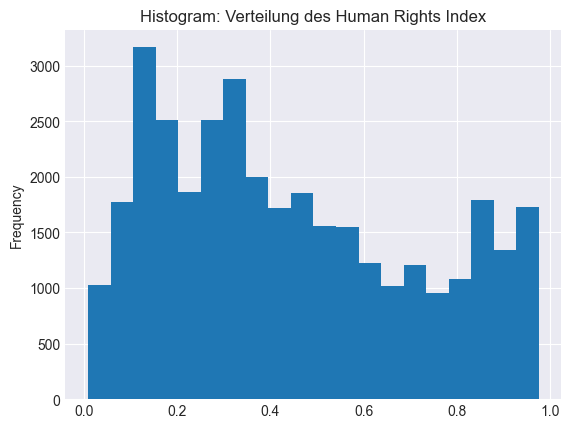

In [136]:
df['Human Rights Index'].plot.hist(
    bins=20,
    title="Histogram: Verteilung des Human Rights Index"
)


**Boxplot des Human Rights Index**

Median Human Rights Index: 0.385


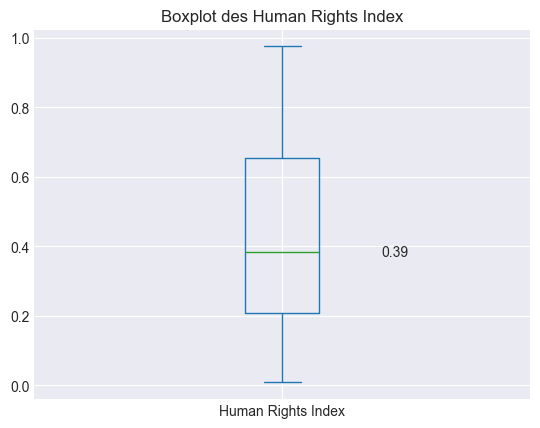

In [137]:
import matplotlib.pyplot as plt

# Boxplot
ax = df["Human Rights Index"].plot.box(
    title="Boxplot des Human Rights Index"
)

# Median als Zahl berechnen und ausgeben
median = df["Human Rights Index"].median()
print("Median Human Rights Index:", median)

# Median zusätzlich im Plot beschriften
ax.text(
    1.2, median,        # x-Position leicht rechts der Box, y = Median
    f"{median:.2f}",     # auf zwei Nachkommastellen
    va="center"
)

plt.show()


**Boxplot pro 50-Jahres-Abschnitt**

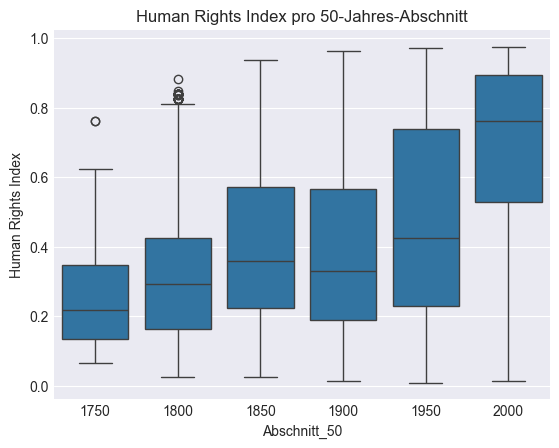

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

# 50-Jahres-Abschnitte bilden
df['Abschnitt_50'] = (df['Jahr'] // 50) * 50

sns.boxplot(
    data=df,
    x='Abschnitt_50',
    y='Human Rights Index'
)

plt.title("Human Rights Index pro 50-Jahres-Abschnitt")
plt.show()



### 3.4 Zusammenhänge zwischen Variablen

Unsere zentralen Variablen sind das **Jahr** und der **Human Rights Index**.

**Streuungsdiagramm (Scatter Plot)**

<Axes: title={'center': 'Zusammenhang zwischen Jahr und Human Rights Index'}, xlabel='Jahr', ylabel='Human Rights Index'>

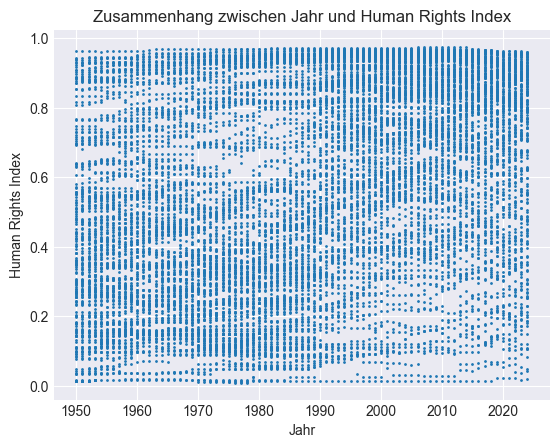

In [139]:


df[df["Jahr"].between(1950, 2024)].plot.scatter(
    x="Jahr",
    y="Human Rights Index",
    s=1,
    title="Zusammenhang zwischen Jahr und Human Rights Index"
)



**Pivot-Tabelle zur Visualisierung der Daten am Beispiel der Schweiz**

<Axes: title={'center': 'Veränderung des Human Rights Index – Switzerland'}, xlabel='Jahr', ylabel='Human Rights Index'>

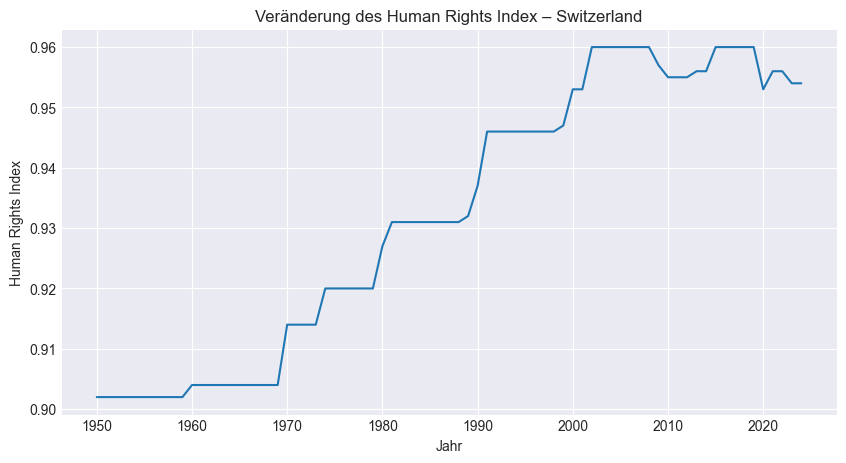

In [140]:

pivot = df.pivot_table(
    index="Jahr",
    columns="Land",
    values="Human Rights Index"
)

land = "Switzerland"

pivot.loc[1950:2024, land].plot(
    title=f"Veränderung des Human Rights Index – {land}",
    xlabel="Jahr",
    ylabel="Human Rights Index",
    grid=True,
    figsize=(10, 5)
)


## 4. Statistik der relevanten Daten (1950-2024)
In diesem Abschnitt werden die Daten erneut statistisch dargestellt, nun jedoch auf den Zeitraum von **1950 bis 2024** gefiltert. Dies ermöglicht eine gezielte Analyse der für unsere Fragestellung relevanten Jahre.

### 4.1 Anzahl der Datenpunkte

In [ ]:
df.loc[1950:2024, 'Human Rights Index'].count()


### 4.2 Fehlen Datenpunkte?

### 4.3 Verteilung der Variable (Histogram, Boxplot, Säulendiagramm)

**Histogramm zwischen 1950-2024** 

**Boxplot zwischen 1950-2024**

<Axes: title={'center': 'Boxplot des Human Rights Index'}>

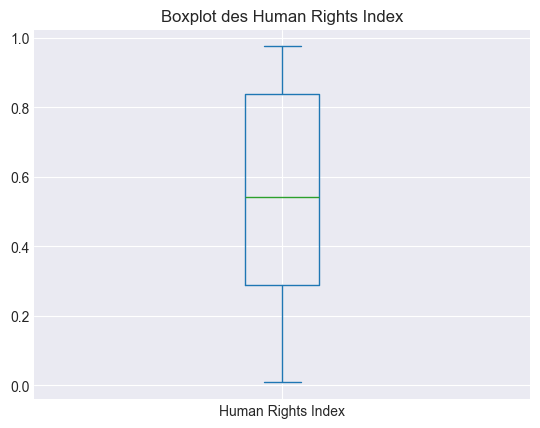

In [141]:
df[df["Jahr"].between(1950, 2024)]["Human Rights Index"].plot.box(
    title="Boxplot des Human Rights Index"
)

## 5. Analyse


### 5.1 Abschliessende Visualisierung

Fragestellung: 

<span style="color:blue; font-weight:bold"> Wie haben sich die Menschenrechte in verschiedenen Ländern in den letzten Jahren entwickelt, und welche drei Staaten verzeichnen die stärksten Verbesserungen bzw. Verschlechterungen zwischen 1950 und 2024?</span> 

**Daten vorbereiten**

In [142]:

# Zeitraum filtern
df_filtered = df[(df["Jahr"] >= 1950) & (df["Jahr"] <= 2024)]

# Pivot-Tabelle: Jahre als Index, Länder als Spalten
pivot = df_filtered.pivot_table(
    index="Jahr",
    columns="Land",
    values="Human Rights Index"
)


**Berechnung der Veränderung 1950 bis 2024**

Der Code berechnet für jedes Land die Veränderung des Human Rights Index zwischen 1950 und 2024, identifiziert daraus die drei Länder mit den größten Verbesserungen und die drei mit den stärksten Verschlechterungen und stellt diese übersichtlich in Tabellen dar.

In [ ]:

start_values = pivot.loc[1950]
end_values = pivot.loc[2024]

diff = end_values - start_values

top_improvements = diff.sort_values(ascending=False).head(3)

top_declines = diff.sort_values(ascending=True).head(3)

import pandas as pd

print("Die stärksten Verbesserungen (1950–2024):")
df_improve = pd.DataFrame({
    "Land": top_improvements.index,
    "Veränderung": top_improvements.values
})
display(df_improve)

print("Die stärksten Verschlechterungen (1950–2024):")
df_decline = pd.DataFrame({
    "Land": top_declines.index,
    "Veränderung": top_declines.values
})
display(df_decline)

**Visualisieren der Fragesellung spezifischen Daten.**

Dank der Berechnung der Länder mit der stärksten positiven Veränderung sowie der stärksten negativen Veränderung im Human Rights Index können wir die Daten nun in einer letzten, anschaulichen Grafik darstellen.
Dazu wurden die beiden Gruppen der Länder als Variablen gespeichert:

In [144]:

laender1 = list(top_improvements.index)
laender2 = list(top_declines.index)



**Stärkste Verbesserungen**

Die zugrunde liegenden Daten werden ausführlich im Abschnitt 5.2 erläutert.

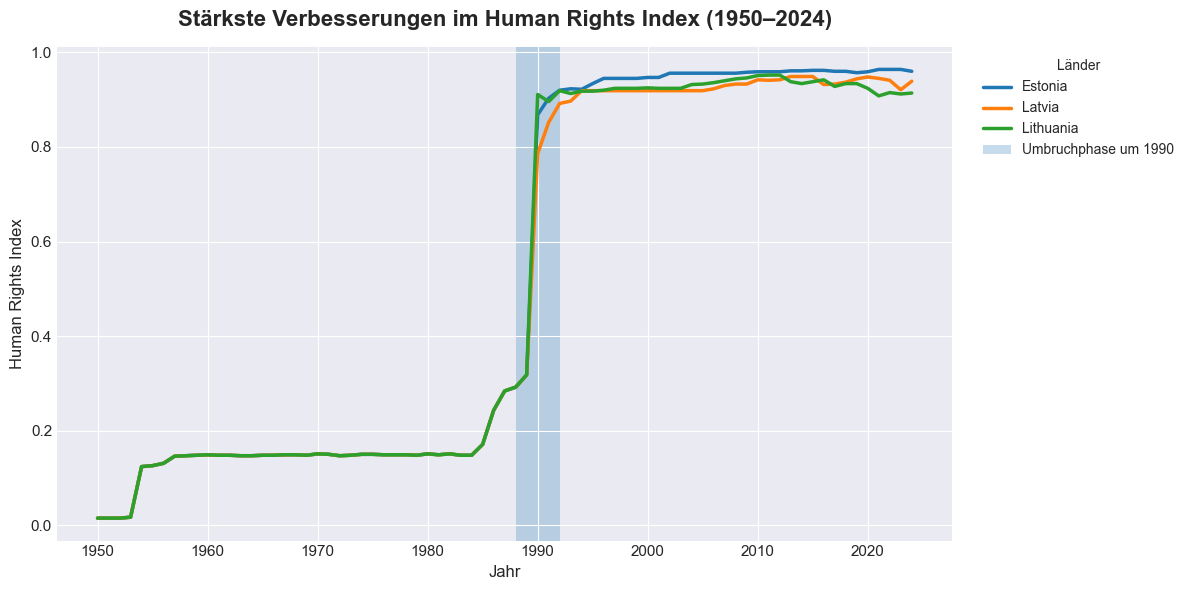

In [145]:


plt.style.use("seaborn-v0_8-darkgrid")

ax = pivot[laender1].plot(
    figsize=(12, 6),
    linewidth=2.5
)


ax.axvspan(
    1988, 1992,
    alpha=0.25,
    zorder=0,
    label="Umbruchphase um 1990"
)

ax.set_title(
    "Stärkste Verbesserungen im Human Rights Index (1950–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Human Rights Index", fontsize=12)

ax.legend(
    title="Länder",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()


**Stärkste Verschlechterungen**

Die zugrunde liegenden Daten werden ausführlich im Abschnitt 5.2 erläutert.

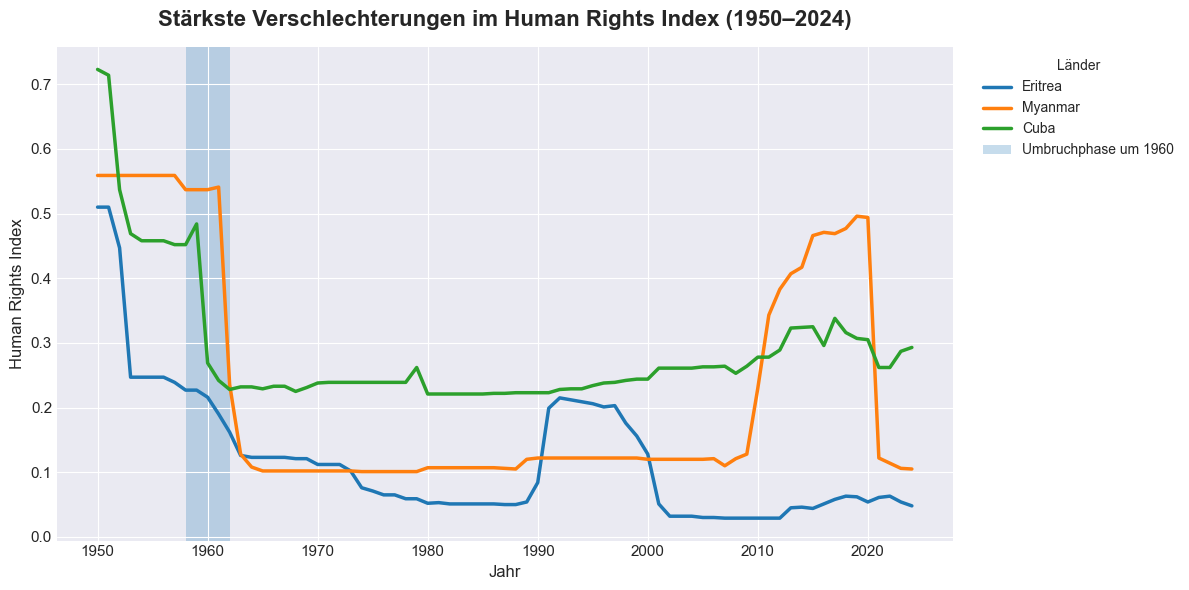

In [146]:


plt.style.use("seaborn-v0_8-darkgrid")

ax = pivot[laender2].plot(
    figsize=(12, 6),
    linewidth=2.5
)

ax.axvspan(
    1958, 1962,  
    alpha=0.25,
    zorder=0,
    label="Umbruchphase um 1960"
)

ax.set_title(
    "Stärkste Verschlechterungen im Human Rights Index (1950–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Jahr", fontsize=12)
ax.set_ylabel("Human Rights Index", fontsize=12)


ax.legend(
    title="Länder",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)


ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


### 5.2 Beschreibung der Beobachtungen
**Stärkste Verbesserungen des Human Rights Index**


<span style="color:blue; font-weight:bold"> Estonia</span>


Beschreibung:



<span style="color:blue; font-weight:bold"> Latvia</span>


Beschreibung:



<span style="color:blue; font-weight:bold"> Lithuania</span>



Beschreibung:


**Stärkste Verschlechterungen des Human Rights Index**



<span style="color:red; font-weight:bold"> Erithrea</span>


Beschreibung:


<span style="color:red; font-weight:bold"> Myanmar</span>



Beschreibung:


<span style="color:red; font-weight:bold"> Cuba</span>



Beschreibung:


### 5.3 Interpretation der Resultate (Hypothesen zu den Resultaten)


In [ ]:
from IPython.display import Image, display

Interpretation der Resultate und deren Untermauerung durch Hinweise auf einschlägige Literatur.

**Stärkste Verbesserungen des Human Rights Index**


<span style="color:blue; font-weight:bold"> Estonia</span> <img src="ee.png" width="200" style="float:right; margin:10px">




Interpretation:


Quelle:




<span style="color:blue; font-weight:bold"> Latvia</span> <img src="lv.png" width="200" style="float:right; margin:10px">




Interpretation:


Quelle:




<span style="color:blue; font-weight:bold"> Lithuania</span> <img src="lt.png" width="200" style="float:right; margin:10px">



Interpretation:


Quelle:




**Stärkste Verschlechterungen des Human Rights Index**





<span style="color:red; font-weight:bold"> Erithrea</span> <img src="er.png" width="200" style="float:right; margin:10px">


Interpretation:


Quelle:




<span style="color:red; font-weight:bold"> Myanmar</span> <img src="mm.png" width="200" style="float:right; margin:10px">



Interpretation:


Quelle:




<span style="color:red; font-weight:bold"> Cuba</span> <img src="cu.png" width="200" style="float:right; margin:10px">



Interpretation:


Quelle:


### 5.3 Abschliessende Worte zum Dokument